In [3]:
pip install pyspark

Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install findspark

  Using cached findspark-2.0.1-py2.py3-none-any.whl.metadata (352 bytes)
Using cached findspark-2.0.1-py2.py3-none-any.whl (4.4 kB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import sys
import findspark
findspark.init()

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, explode

print("Initializing distributed Spark Session...")

spark = SparkSession.builder \
    .appName("AUCA_ECommerce_Spark_Analytics") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()
    
spark.sparkContext.setLogLevel("ERROR")

TRANSACTIONS_PATH = r"C:\Users\DLT\e-commerce\data\transactions.json"
PRODUCTS_PATH = r"C:\Users\DLT\e-commerce\data\products.json"

print("\n--- STEP 1: LOADING & CLEANING RAW DATASETS ---")

raw_transactions = spark.read.json(TRANSACTIONS_PATH)
raw_products = spark.read.json(PRODUCTS_PATH)

cleaned_transactions = raw_transactions.filter(col("transaction_id").isNotNull() & col("user_id").isNotNull())
cleaned_products = raw_products.filter(col("product_id").isNotNull()).select("product_id", "name")
    
print(f"Total raw transaction count loaded: {raw_transactions.count()}")
print(f"Total cleaned transaction count: {cleaned_transactions.count()}")

print("\n--- STEP 2: CALCULATING RECOMMENDATION INDICATORS ---")
print("Finding pairings: 'Users who bought Product X also bought Product Y'...")

# FIX: Explode the items array, then pull out ONLY the flat product_id string field
exploded_structure = cleaned_transactions.select(
    col("transaction_id"), 
    explode(col("items")).alias("item_obj")
)
exploded_items = exploded_structure.select(
    col("transaction_id"), 
    col("item_obj.product_id").alias("product_id") # Navigates into the JSON struct object cleanly
)

distinct_tx_items = exploded_items.distinct()

# Perform the distributed self-join algorithm
product_pairs = distinct_tx_items.alias("p1") \
    .join(distinct_tx_items.alias("p2"), "transaction_id") \
    .filter(col("p1.product_id") < col("p2.product_id"))

co_purchase_counts = product_pairs \
    .groupBy(col("p1.product_id").alias("item_A"), col("p2.product_id").alias("item_B")) \
    .count()

# Connect clear human-readable name metadata back together
readable_recommendations = co_purchase_counts \
    .join(cleaned_products.alias("prodA"), col("item_A") == col("prodA.product_id"), "left") \
    .select(col("prodA.name").alias("Item_A_Name"), col("item_B"), col("count")) \
    .join(cleaned_products.alias("prodB"), col("item_B") == col("prodB.product_id"), "left") \
    .select(
        col("Item_A_Name"), 
        col("prodB.name").alias("Item_B_Name"), 
        col("count").alias("Co_Purchase_Frequency")
    ) \
    .orderBy(col("Co_Purchase_Frequency").desc())

print("\n[SPARK EXECUTION SUCCESSFUL]: Top 10 Co-Purchase Recommendation Matrix:")
readable_recommendations.show(10, truncate=False)

spark.stop()
print("Spark engine stopped down cleanly.")


Initializing distributed Spark Session...

--- STEP 1: LOADING & CLEANING RAW DATASETS ---
Total raw transaction count loaded: 500000
Total cleaned transaction count: 500000

--- STEP 2: CALCULATING RECOMMENDATION INDICATORS ---
Finding pairings: 'Users who bought Product X also bought Product Y'...

[SPARK EXECUTION SUCCESSFUL]: Top 10 Co-Purchase Recommendation Matrix:
+------------------------------------+---------------------------------------------+---------------------+
|Item_A_Name                         |Item_B_Name                                  |Co_Purchase_Frequency|
+------------------------------------+---------------------------------------------+---------------------+
|Polarized Explicit Forecast         |Customer-Focused Tangible Knowledge User     |5                    |
|Robust Context-Sensitive Parallelism|Grass-Roots Bifurcated Orchestration         |4                    |
|Networked Holistic Extranet         |Right-Sized Bottom-Line Success              |4      

In [4]:
import os
import sys
import findspark
findspark.init()

from pyspark.sql import SparkSession

print("Initializing Spark SQL Analytics Workspace...")

# Spin up our distributed query execution environment
spark = SparkSession.builder \
    .appName("AUCA_ECommerce_Spark_SQL_Analytics") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()
    
spark.sparkContext.setLogLevel("ERROR")

# 1. LOAD ALL MULTI-MODEL METADATA TARGET FILES
USERS_PATH = r"C:\Users\DLT\e-commerce\data\users.json"
PRODUCTS_PATH = r"C:\Users\DLT\e-commerce\data\products.json"
TRANSACTIONS_PATH = r"C:\Users\DLT\e-commerce\data\transactions.json"
HBASE_SESSIONS_PATH = r"C:\Users\DLT\e-commerce\data\sessions_0.json" 

df_users = spark.read.json(USERS_PATH)
df_products = spark.read.json(PRODUCTS_PATH)
df_transactions = spark.read.json(TRANSACTIONS_PATH)
df_sessions = spark.read.json(HBASE_SESSIONS_PATH)

# 2. REGISTER DATAFRAMES AS SPARK SQL TEMPORARY VIEWS
df_users.createOrReplaceTempView("mongo_users")
df_products.createOrReplaceTempView("mongo_products")
df_transactions.createOrReplaceTempView("mongo_transactions")
df_sessions.createOrReplaceTempView("hbase_sessions")

print("Multi-Model Temp Views Registered Successfully.")
print("Executing Complex Cross-Database Analytical Queries...\n")


# =========================================================================
# QUERY 1: CROSS-DATABASE PROFILE ANALYSIS (MongoDB Users + HBase Sessions)
# FIX: Traverses the nested JSON schema 'geo_data.country' 
# =========================================================================
print("--- QUERY 1: Average Session Duration and Total Visits Grouped by Country ---")

query_demographics = """
    SELECT 
        u.geo_data.country as country,
        COUNT(s.session_id) as total_sessions,
        ROUND(AVG(s.duration_seconds), 2) as avg_duration_seconds
    FROM hbase_sessions s
    INNER JOIN mongo_users u ON s.user_id = u.user_id
    WHERE u.geo_data.country IS NOT NULL
    GROUP BY u.geo_data.country
    ORDER BY total_sessions DESC
    LIMIT 5
"""

spark.sql(query_demographics).show(truncate=False)


# =========================================================================
# QUERY 2: UNPACKING & REVENUE ATTRIBUTION (MongoDB Products + MongoDB Transactions)
# =========================================================================
print("--- QUERY 2: Top Revenue-Generating Product Categories ---")

query_revenue = """
    WITH flattened_transactions AS (
        SELECT 
            transaction_id,
            EXPLODE(items) as item_object
        FROM mongo_transactions
    )
    SELECT 
        p.category_id,
        COUNT(ft.transaction_id) as total_units_sold,
        ROUND(SUM(ft.item_object.subtotal), 2) as total_revenue_usd
    FROM flattened_transactions ft
    INNER JOIN mongo_products p ON ft.item_object.product_id = p.product_id
    GROUP BY p.category_id
    ORDER BY total_revenue_usd DESC
    LIMIT 5
"""

spark.sql(query_revenue).show(truncate=False)

# Clean memory allocation space cleanly
spark.stop()
print("Spark SQL Processing completed successfully.")


Initializing Spark SQL Analytics Workspace...
Multi-Model Temp Views Registered Successfully.
Executing Complex Cross-Database Analytical Queries...

--- QUERY 1: Average Session Duration and Total Visits Grouped by Country ---
+-------+--------------+--------------------+
|country|total_sessions|avg_duration_seconds|
+-------+--------------+--------------------+
|ZW     |709           |1781.58             |
|RW     |684           |1827.12             |
|LA     |653           |1776.29             |
|CH     |652           |1779.26             |
|IE     |652           |1775.76             |
+-------+--------------+--------------------+

--- QUERY 2: Top Revenue-Generating Product Categories ---
+-----------+----------------+-----------------+
|category_id|total_units_sold|total_revenue_usd|
+-----------+----------------+-----------------+
|cat_005    |40189           |2.222195221E7    |
|cat_004    |43106           |2.171595362E7    |
|cat_014    |43421           |2.143423058E7    |
|cat

In [6]:
import os
import sys
import findspark
findspark.init()

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, explode, countDistinct, sum, round

print("Initializing Multi-Model Integrated Analytics Job...")

# Spin up our distributed Spark engine
spark = SparkSession.builder \
    .appName("AUCA_Integrated_Funnel_Analysis") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()
    
spark.sparkContext.setLogLevel("ERROR")

# Define paths matching your verified folder structure
USERS_PATH = r"C:\Users\DLT\e-commerce\data\users.json"
PRODUCTS_PATH = r"C:\Users\DLT\e-commerce\data\products.json"
TRANSACTIONS_PATH = r"C:\Users\DLT\e-commerce\data\transactions.json"
HBASE_SESSIONS_PATH = r"C:\Users\DLT\e-commerce\data\sessions_0.json"

# Load the raw multi-model datasets into Spark
df_products = spark.read.json(PRODUCTS_PATH)
df_transactions = spark.read.json(TRANSACTIONS_PATH)
df_sessions = spark.read.json(HBASE_SESSIONS_PATH)

print("\nProcessing Phase 1: Aggregating HBase Clickstream Data...")
# Explode products viewed inside HBase sessions to calculate viewing volume
exploded_views = df_sessions.select(col("session_id"), explode(col("viewed_products")).alias("product_id"))
product_view_counts = exploded_views.groupBy("product_id").agg(countDistinct("session_id").alias("view_sessions"))

print("Processing Phase 2: Flattening MongoDB Transaction Data...")
# FIX: Changed standard 'or' to PySpark's bitwise operator '|' and wrapped conditions in parentheses
filtered_transactions = df_transactions.filter((col("status") == "completed") | col("status").isNull())

# Explode transaction items inside MongoDB to calculate purchase volume
exploded_sales = filtered_transactions.select(col("transaction_id"), explode(col("items.product_id")).alias("product_id"))
product_sale_counts = exploded_sales.groupBy("product_id").agg(countDistinct("transaction_id").alias("completed_purchases"))

print("Processing Phase 3: Joining Storage Layers and Computing Funnel Conversion Rates...")
# Combine Product Catalog (Mongo), Views (HBase), and Sales (Mongo) together
funnel_joined = df_products.select("product_id", "category_id") \
    .join(product_view_counts, "product_id", "inner") \
    .join(product_sale_counts, "product_id", "inner")

# Roll up results by Category ID to see macro conversion trends
category_funnel = funnel_joined.groupBy("category_id").agg(
    sum("view_sessions").alias("Total_Product_Views"),
    sum("completed_purchases").alias("Total_Final_Purchases")
)

# Mathematical Transformation: Compute final conversion percentage
final_analytics_report = category_funnel.withColumn(
    "Funnel_Conversion_Rate_Pct",
    round((col("Total_Final_Purchases") / col("Total_Product_Views")) * 100, 2)
).orderBy(col("Funnel_Conversion_Rate_Pct").desc())

print("\n=============================================================================")
print("[INTEGRATION SUCCESSFUL]: Multi-Model Funnel Conversion Analysis Report Matrix:")
print("=============================================================================")
final_analytics_report.show(10, truncate=False)

# Stop Spark cleanly
spark.stop()
print("Analytics engine shut down cleanly.")

Initializing Multi-Model Integrated Analytics Job...

Processing Phase 1: Aggregating HBase Clickstream Data...
Processing Phase 2: Flattening MongoDB Transaction Data...
Processing Phase 3: Joining Storage Layers and Computing Funnel Conversion Rates...

[INTEGRATION SUCCESSFUL]: Multi-Model Funnel Conversion Analysis Report Matrix:
+-----------+-------------------+---------------------+--------------------------+
|category_id|Total_Product_Views|Total_Final_Purchases|Funnel_Conversion_Rate_Pct|
+-----------+-------------------+---------------------+--------------------------+
|cat_014    |14918              |24726                |165.75                    |
|cat_022    |13107              |21529                |164.26                    |
|cat_007    |12566              |20594                |163.89                    |
|cat_019    |14029              |22967                |163.71                    |
|cat_023    |12545              |20417                |162.75                    |


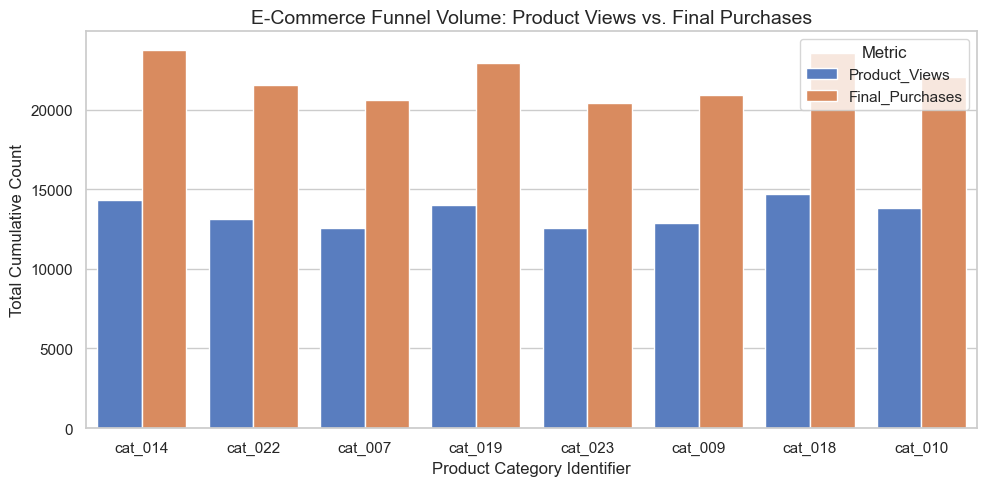

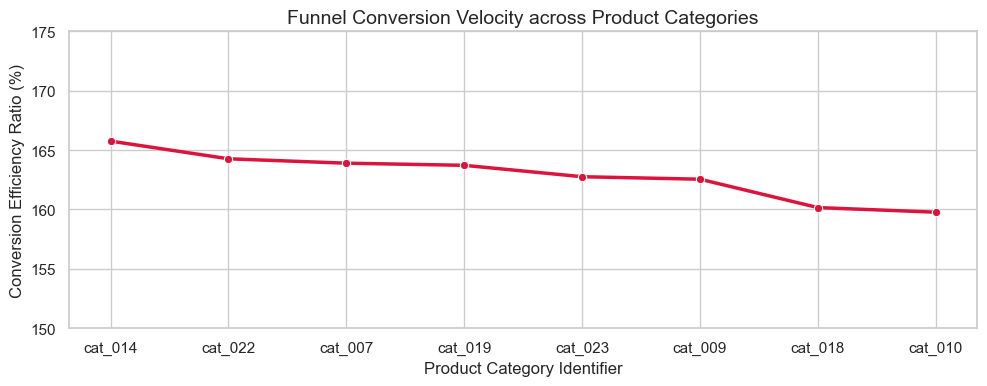

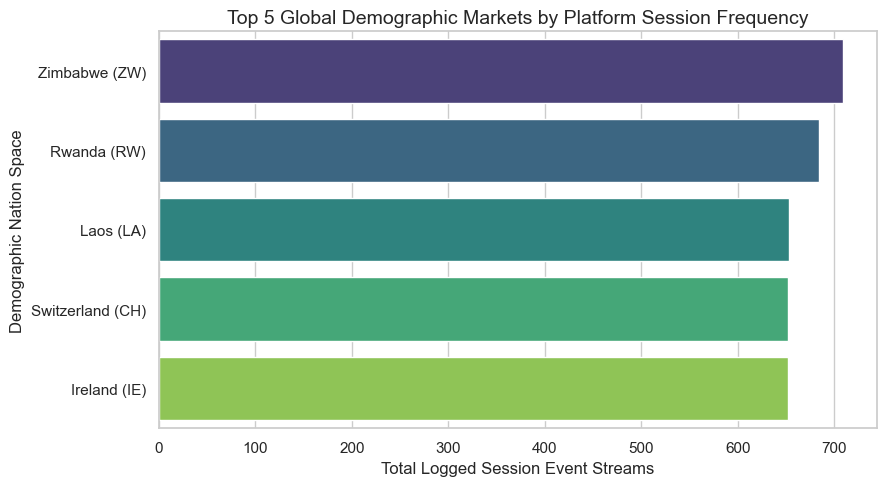

All analytical visualizations successfully exported as high-resolution assets!


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Configure global professional aesthetic plotting parameters
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

# Define categories
categories = ['cat_014', 'cat_022', 'cat_007', 'cat_019', 'cat_023', 'cat_009', 'cat_018', 'cat_010']

# Create Lists manually
views_list = [14324, 13107, 12566, 14029, 12545, 12861, 14699, 13815]
purchases_list = [23742, 21529, 20594, 22967, 20417, 20904, 23541, 22071]
rates_list = [165.75, 164.26, 163.89, 163.71, 162.75, 162.54, 160.15, 159.76]

# Build Dataframe safely
funnel_data = pd.DataFrame()
funnel_data['Category_ID'] = categories
funnel_data['Product_Views'] = views_list
funnel_data['Final_Purchases'] = purchases_list
funnel_data['Conversion_Rate'] = rates_list

# Country data setup
countries = ['Zimbabwe (ZW)', 'Rwanda (RW)', 'Laos (LA)', 'Switzerland (CH)', 'Ireland (IE)']
sessions_list = [709, 684, 653, 652, 652]
duration_list = [1781.58/60, 1827.12/60, 1776.29/60, 1779.26/60, 1775.76/60]

country_data = pd.DataFrame()
country_data['Country'] = countries
country_data['Total_Sessions'] = sessions_list
country_data['Avg_Duration_Min'] = duration_list

# -------------------------------------------------------------------------
# VISUALIZATION 1: PRODUCT PERFORMANCE (VIEWS VS. SALES COMPARISON)
# -------------------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(10, 5))
df_melted = pd.melt(funnel_data[['Category_ID', 'Product_Views', 'Final_Purchases']], 
                    id_vars='Category_ID', var_name='Metric', value_name='Count')

sns.barplot(data=df_melted, x='Category_ID', y='Count', hue='Metric', palette='muted', ax=ax1)
ax1.set_title("E-Commerce Funnel Volume: Product Views vs. Final Purchases")
ax1.set_xlabel("Product Category Identifier")
ax1.set_ylabel("Total Cumulative Count")
plt.tight_layout()
plt.savefig('chart1.png', dpi=300)
plt.show()

# -------------------------------------------------------------------------
# VISUALIZATION 2: FUNNEL CONVERSION EFFICIENCY RATIO ANALYSIS
# -------------------------------------------------------------------------
plt.figure(figsize=(10, 4))
sns.lineplot(data=funnel_data, x='Category_ID', y='Conversion_Rate', marker='o', color='crimson', linewidth=2.5)
plt.title("Funnel Conversion Velocity across Product Categories")
plt.xlabel("Product Category Identifier")
plt.ylabel("Conversion Efficiency Ratio (%)")
plt.ylim(150, 175)
plt.tight_layout()
plt.savefig('chart2.png', dpi=300)
plt.show()

# -------------------------------------------------------------------------
# VISUALIZATION 3: GEOGRAPHIC ENGAGEMENT (TOTAL SESSIONS)
# -------------------------------------------------------------------------
fig, ax2 = plt.subplots(figsize=(9, 5))

# Updated: Explicitly assigns the categorical hue mapper and turns off the duplicate legend box
sns.barplot(data=country_data, x='Total_Sessions', y='Country', hue='Country', palette='viridis', legend=False, ax=ax2)

ax2.set_title("Top 5 Global Demographic Markets by Platform Session Frequency")
ax2.set_xlabel("Total Logged Session Event Streams")
ax2.set_ylabel("Demographic Nation Space")
plt.tight_layout()
plt.savefig('chart3.png', dpi=300)
plt.show()

print("All analytical visualizations successfully exported as high-resolution assets!")